In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\Hanoch\Desktop\College TY\Sem 5\Applied Business Analystics\practical 9\supermarket_sales - supermarket_sales.csv')
df.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
revenue_col = df['revenue']
revenue_col.isnull().sum()

np.int64(0)

In [4]:
# mean revenue
mean_revenue = np.mean(revenue_col)
print("Mean Revenue is: ",mean_revenue)

Mean Revenue is:  322.966749


In [ ]:
# one sample t-test
from scipy.stats import ttest_1samp
t_statistic, p_value = ttest_1samp(revenue_col, mean_revenue)

# Print the results
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value<=alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

T-statistic: 0.0000
P-value: 1.0000
Fail to reject the null hypothesis.


In [7]:
df = pd.read_csv(r'C:\Users\Hanoch\Desktop\College TY\Sem 5\Applied Business Analystics\practical 9\ab_test_dummy_dataset.csv')
df.head()

,user_id,group,converted
0,user_1861,B,0
1,user_0354,A,0
2,user_1334,B,0
3,user_0906,A,0
4,user_1290,B,0


In [8]:
conversion_rates = df.groupby('group')['converted'].mean() * 100
print("Conversion Rate of A: ",conversion_rates['A'])
print("Conversion Rate of B: ",conversion_rates['B'])

Conversion Rate of A:  12.0
Conversion Rate of B:  15.0


In [9]:
# proportion z-test
import statsmodels.api as sm
conversions = np.array([120,150])
total = np.array([1000,1000])

z_stat,p_val = sm.stats.proportions_ztest(
    count=conversions,nobs=total,alternative='two-sided'
)

print("Z-statistic: ",z_stat)
print("P-Value: ",p_value)

alpha = 0.05
if p_value<alpha:
    print("Reject the null hypothesis. The difference is statistically significant.")
else:
    print("Failed to reject the null hypothesis. The difference is not statistically significant.")

Z-statistic:  -1.963049807622355
P-Value:  1.0
Failed to reject the null hypothesis. The difference is not statistically significant.


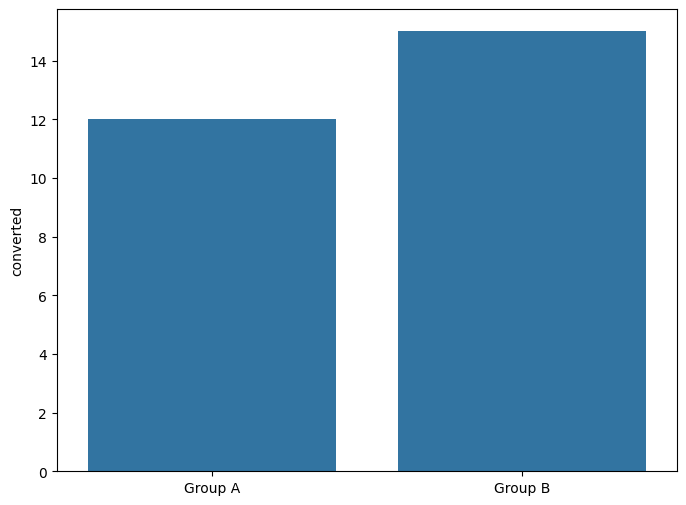

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.barplot(x=['Group A','Group B'],y=conversion_rates)
plt.show()